# Coffee Sales Data Visualization Refinement
This notebook demonstrates an agentic workflow to generate and refine a data visualization chart using LLM feedback.


In [1]:
# Standard library imports
import re

# Local helper module
import src.utils as utils
from src.agents import generate_chart_code, reflect_on_image_and_regenerate


# 1. Configuration & Data Loading
Define the visualization instruction and the LLM model to use, then load the coffee sales data.


In [2]:
# Configuration
INSTRUCTION = "Create a plot comparing Q1 coffee sales in 2024 and 2025 using the data in coffee_sales.csv."
MODEL_NAME = "gpt-5-mini" # or use a Claude model if needed

# Data loading
df = utils.load_and_prepare_data('static/coffee_sales.csv')

# Preview the data
utils.print_html(df.sample(n=5), title="Random Sample of Coffee Sales Data")


date,time,cash_type,card,price,coffee_name,quarter,month,year
2024-09-09,11:31,card,ANON-0000-0000-0601,2.792,Americano with Milk,3,9,2024
2025-02-14,11:17,card,ANON-0000-0000-1211,3.086,Americano with Milk,1,2,2025
2025-03-12,13:36,card,ANON-0000-0000-1281,3.576,Cappuccino,1,3,2025
2025-02-05,12:25,card,ANON-0000-0000-1164,3.576,Latte,1,2,2025
2024-08-12,09:03,card,ANON-0000-0000-0490,3.282,Latte,3,8,2024


# 2. Generate Initial Chart (V1)
Call the LLM to generate the first version of the chart code based on the user's instruction.


In [3]:
# Generate initial code
code_v1 = generate_chart_code(
    instruction=INSTRUCTION,
    model=MODEL_NAME,
    out_path_v1="out/chart_v1.png"
)

utils.print_html(code_v1, title="LLM output with first draft code")


# 3. Execute Generated Code (V1)
Extract the Python code from the LLM's response and execute it to generate the `chart_v1.png` file.



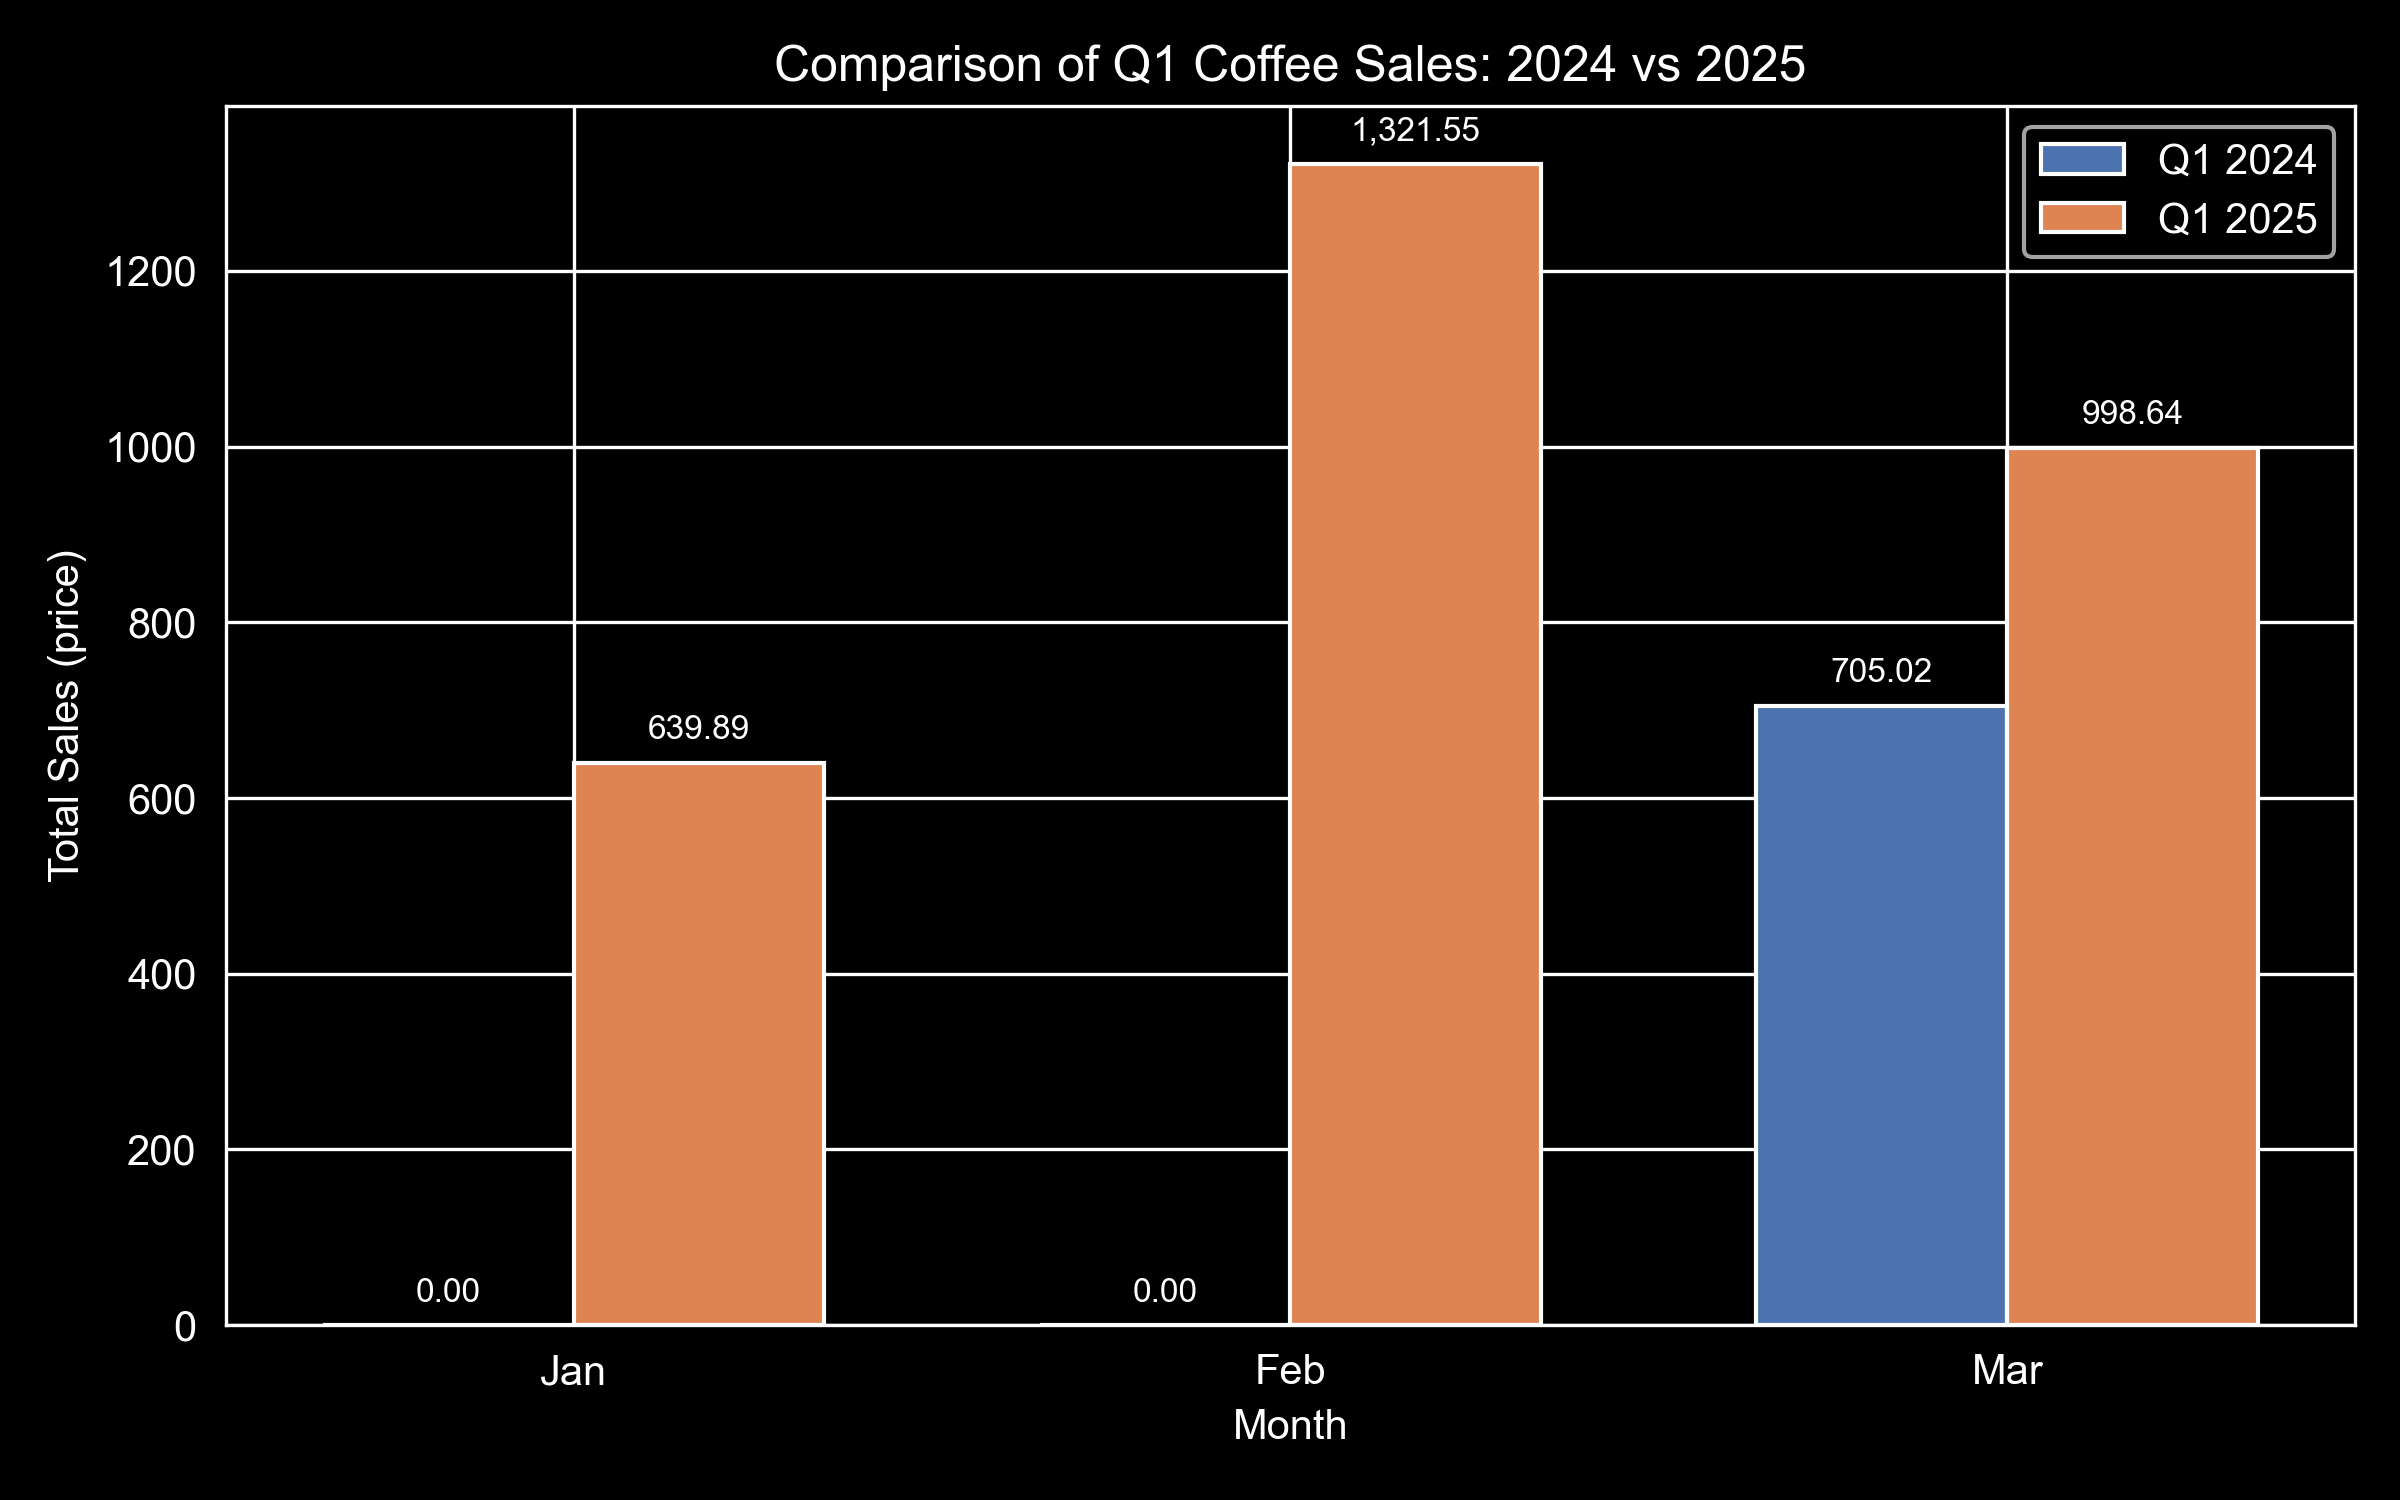

In [4]:
# Extract and execute the code within <execute_python> tags
match_v1 = re.search(r"<execute_python>([\s\S]*?)</execute_python>", code_v1)
if match_v1:
    initial_code = match_v1.group(1).strip()
    utils.print_html(initial_code, title="Extracted Code (V1)")
    exec_globals = {"df": df}
    exec(initial_code, exec_globals)

# Display the generated chart
utils.print_html(
    content="out/chart_v1.png",
    title="Generated Chart (V1)",
    is_image=True
)


# 4. Critique & Refinement (V2)
Reflect on the generated image (V1) and the original code to provide feedback and generate an improved version of the chart.


In [5]:
# Generate feedback and refined code
feedback, code_v2 = reflect_on_image_and_regenerate(
    chart_path="out/chart_v1.png",
    instruction=INSTRUCTION,
    model_name=MODEL_NAME,
    out_path_v2="out/chart_v2.png",
    code_v1=code_v1,
)

utils.print_html(feedback, title="Feedback on V1 Chart")
utils.print_html(code_v2, title="Regenerated Code Output (V2)")


# 5. Execute Refined Code (V2)
Extract the refined Python code and execute it to generate the `chart_v2.png` file.



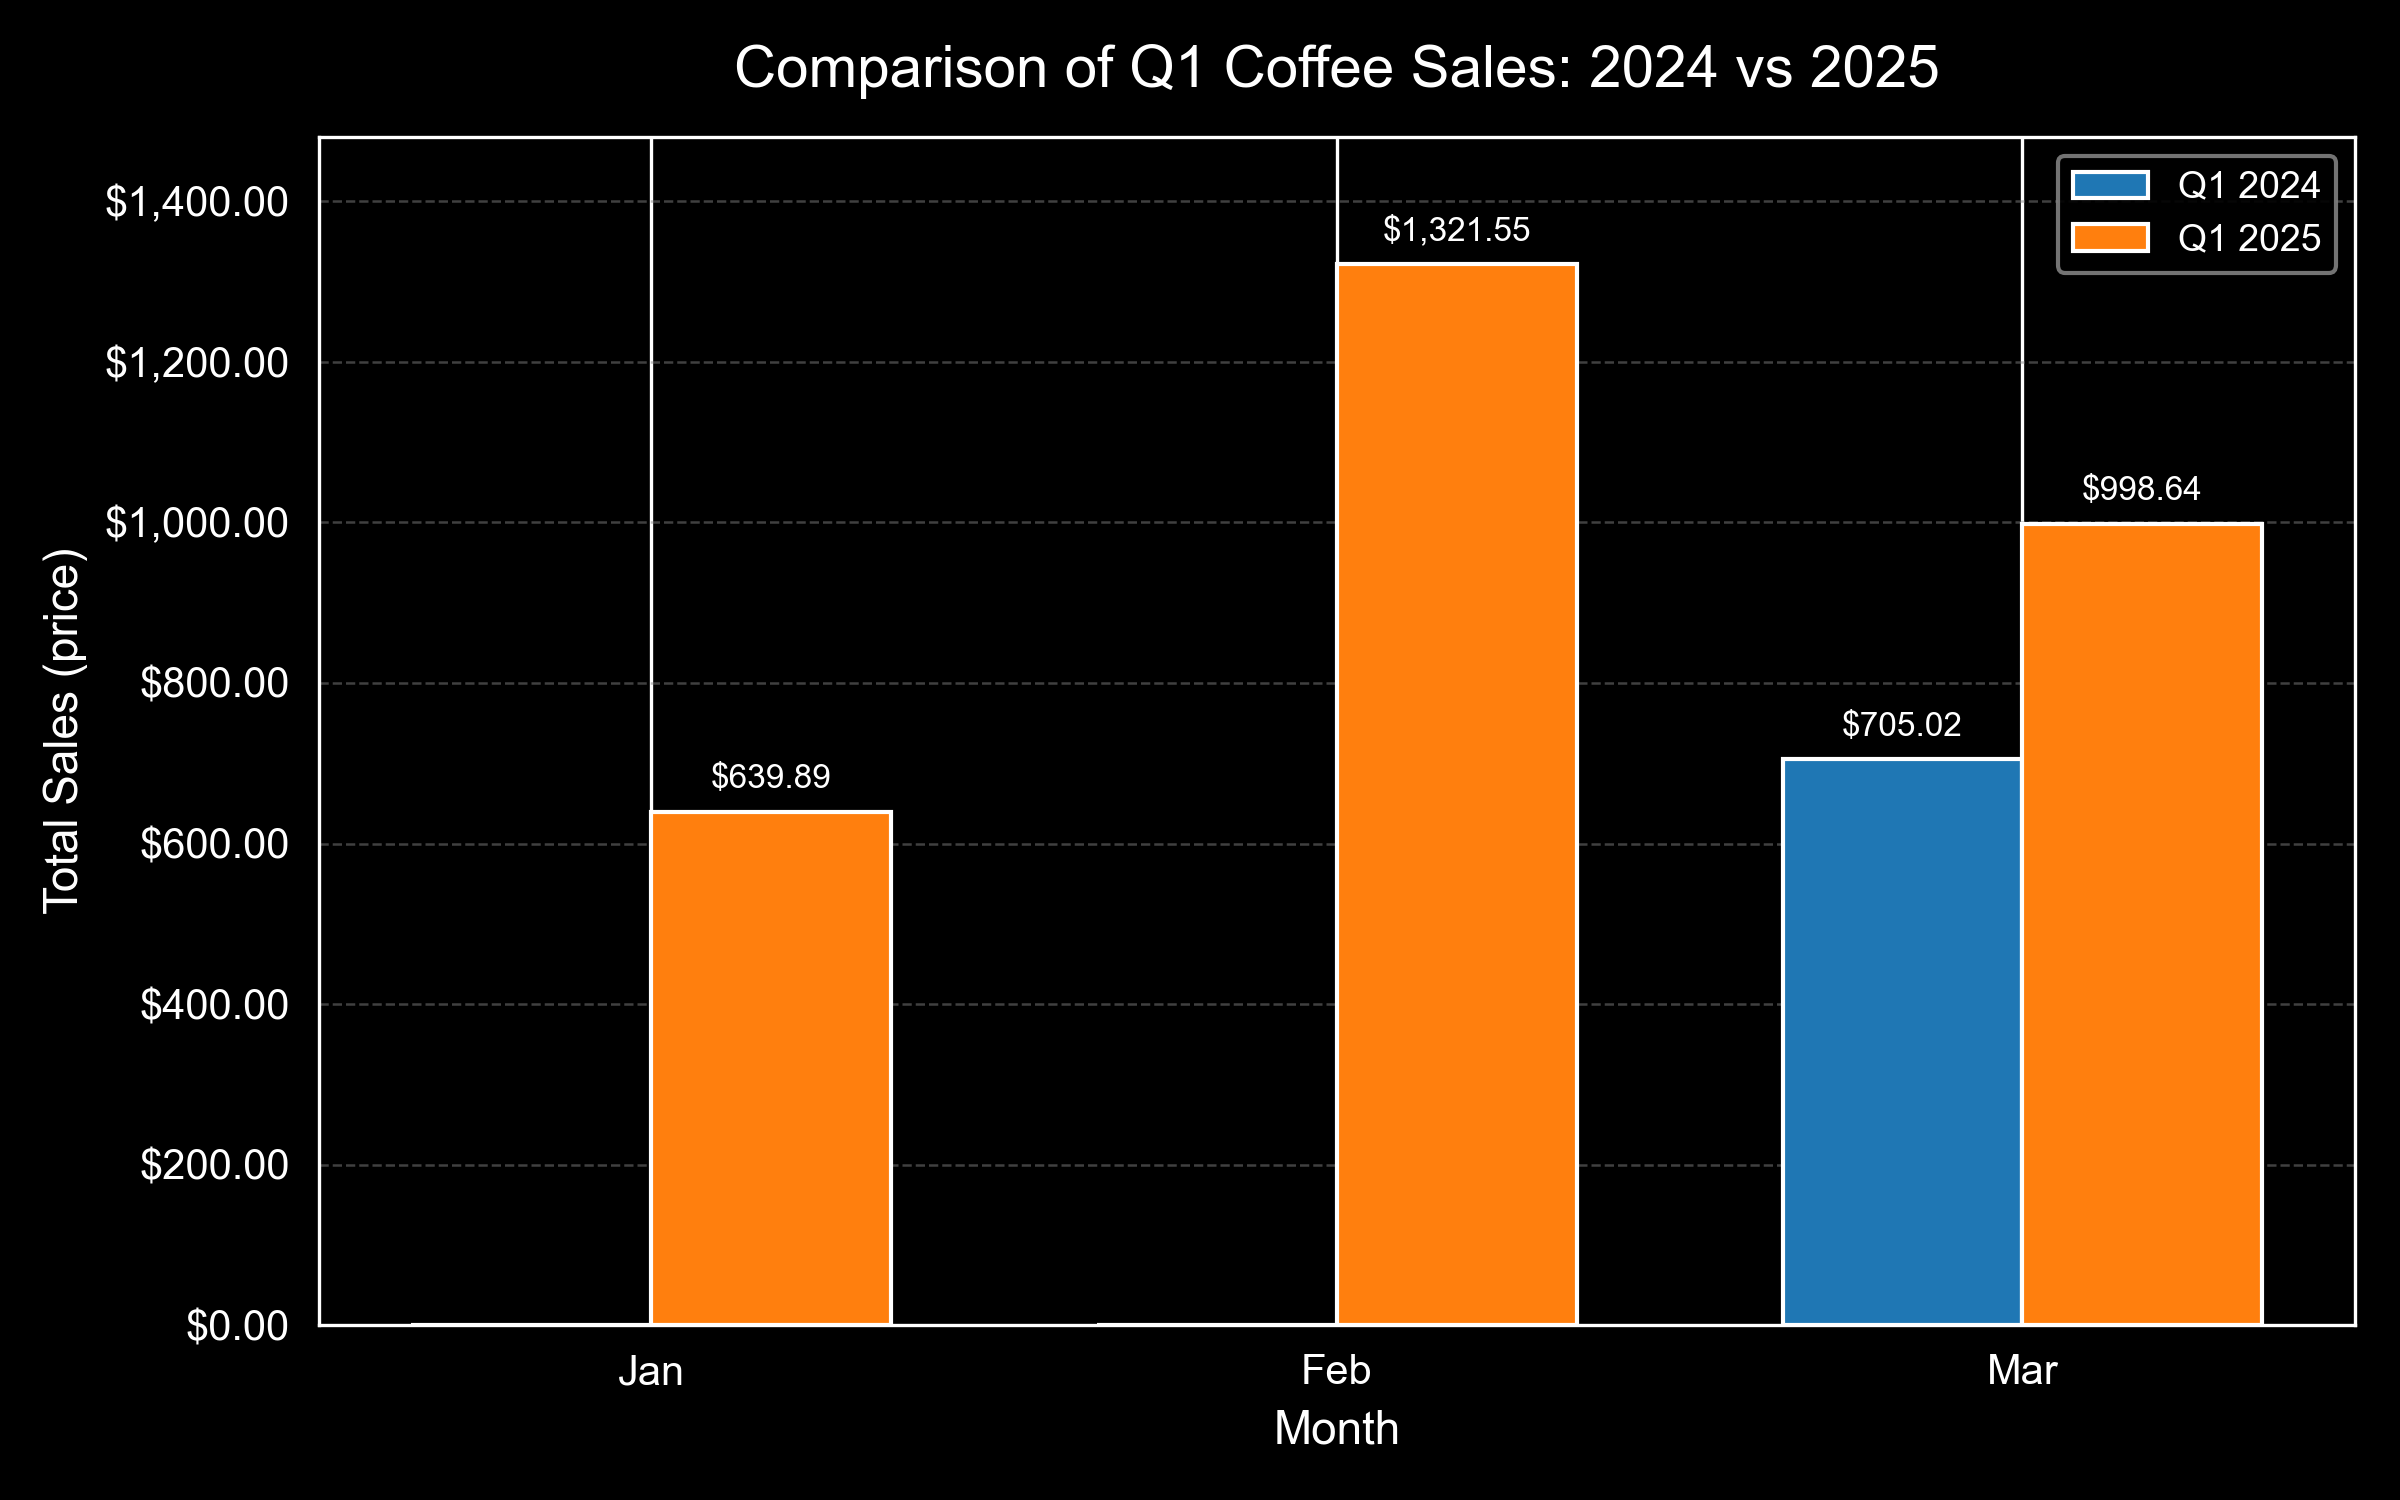

In [6]:
# Extract and execute the refined code
match_v2 = re.search(r"<execute_python>([\s\S]*?)</execute_python>", code_v2)
if match_v2:
    reflected_code = match_v2.group(1).strip()
    utils.print_html(reflected_code, title="Extracted Code (V2)")
    exec_globals = {"df": df}
    exec(reflected_code, exec_globals)

# Display the final refined chart
utils.print_html(
    content="out/chart_v2.png",
    title="Regenerated Chart (V2)",
    is_image=True
)
